In [1]:
import os, sys

import pandas as pd
import numpy as np
import itertools
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.transforms import ScaledTranslation
from matplotlib.lines import Line2D
from pathlib import Path

# repo root
ROOT = Path().resolve().parent

# add src to python path
sys.path.append(str(ROOT / "src"))

import loading as ld
import processing as prc
import visualization as viz

path_to_images = '/Users/Guille/Desktop/india_power/images'
path_to_output = '/Users/Guille/Desktop/india_power/output_csvs'
path_to_csvs = '/Users/Guille/Desktop/india_power/gridpath_india_viz/csvs'
path_to_input = '/Users/Guille/Desktop/india_power/input_data/'

In [2]:
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
load_zones_  = pd.read_csv(path_to_input + r"/load_zones.csv").drop(columns = ['state', 'rps_zone'])

# Main Figure

Coal, Gas, Diesel, Nuclear, Other, Hydro, Solar, Wind, Pumped Storage, Battery, Hydrogen, Transmission Losses. The legend should also read in the same order, although the order doesn’t match the TWh plot because we represent only losses for storage and Tx. And Existing X on top.
Expand Tx to Transmission.


In [3]:
cost_ = {}
cost_['scen_labels'] = pd.read_csv(path_to_csvs + '/cost-scenario_labels.csv') 

cost_['capacity'] = ld._load_capacity(cost_['scen_labels'])
cost_['dispatch'] = ld._load_dispatch(cost_['scen_labels'])

prc._save_technology_capacity_csv(cost_['capacity'], cost_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'cost-capacity.csv')

prc._save_technology_capacity_csv(cost_['dispatch'], cost_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'cost-dispatch.csv')

cost_['capacity'] = prc._group_capacity_by_technology(cost_['capacity'], tech_labels_)
cost_['dispatch'] = prc._group_dispatch_by_technology(cost_['dispatch'], tech_labels_)

prc._save_technology_capacity_csv(cost_['capacity'], cost_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'cost-grouped_capacity.csv')

prc._save_technology_capacity_csv(cost_['dispatch'], cost_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'cost-grouped_dispatch.csv')

VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenar

## Paper Panel Figures 

In [1]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C']], 
                              figsize = (27.5, 7.25), 
                              gridspec_kw = {'width_ratios': [1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 26, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], cost_['capacity'], cost_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 4000,
                                    y_grid_inc = 500)

viz._plot_new_and_existing_storage(_ax['B'], cost_['capacity'], cost_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max = 6000,
                                   y_grid_inc = 750)

viz._plot_dispatch(_ax['C'], cost_['dispatch'], cost_['scen_labels'], tech_labels_, 
                   ylabel = r'Electricity Generation and Losses (TWh)', 
                   legend = True, 
                   y_lim_max = 6000,
                   y_lim_min = -500,
                   y_grid_inc = 750)

line1    = Line2D([], [], color = 'None')
handles_ = [line1, line1, line1, line1, line1, line1]
labels_  = list(cost_['scen_labels']['label'].to_numpy())

leg = _ax['A'].legend(handles_, labels_, 
                      loc = (0., -.525),
                      title = 'Scenarios - Technology Cost (from left to right)',
                      frameon = False,
                      labelspacing = 0.25,
                      title_fontsize = 18,
                      handletextpad = -1.,
                      ncol = 1,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/cost-capacity_generation.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/cost-capacity_generation.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

NameError: name 'plt' is not defined

# Supporting Figues

In [19]:
demand_ = {}
demand_['scen_labels'] = pd.read_csv(path_to_csvs + '/demand-scenario_labels.csv') 

demand_['capacity'] = ld._load_capacity(demand_['scen_labels'])
demand_['dispatch'] = ld._load_dispatch(demand_['scen_labels'])

prc._save_technology_capacity_csv(demand_['capacity'], demand_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'demand-capacity.csv')

prc._save_technology_capacity_csv(demand_['dispatch'], demand_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'demand-dispatch.csv')

demand_['capacity'] = prc._group_capacity_by_technology(demand_['capacity'], tech_labels_)
demand_['dispatch'] = prc._group_dispatch_by_technology(demand_['dispatch'], tech_labels_)

prc._save_technology_capacity_csv(demand_['capacity'], demand_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'demand-grouped_capacity.csv')

prc._save_technology_capacity_csv(demand_['dispatch'], demand_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'demand-grouped_dispatch.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDlow /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDhigh /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERlow /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERhigh /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDlow all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid all /Users/Guille/Desktop/india_power/

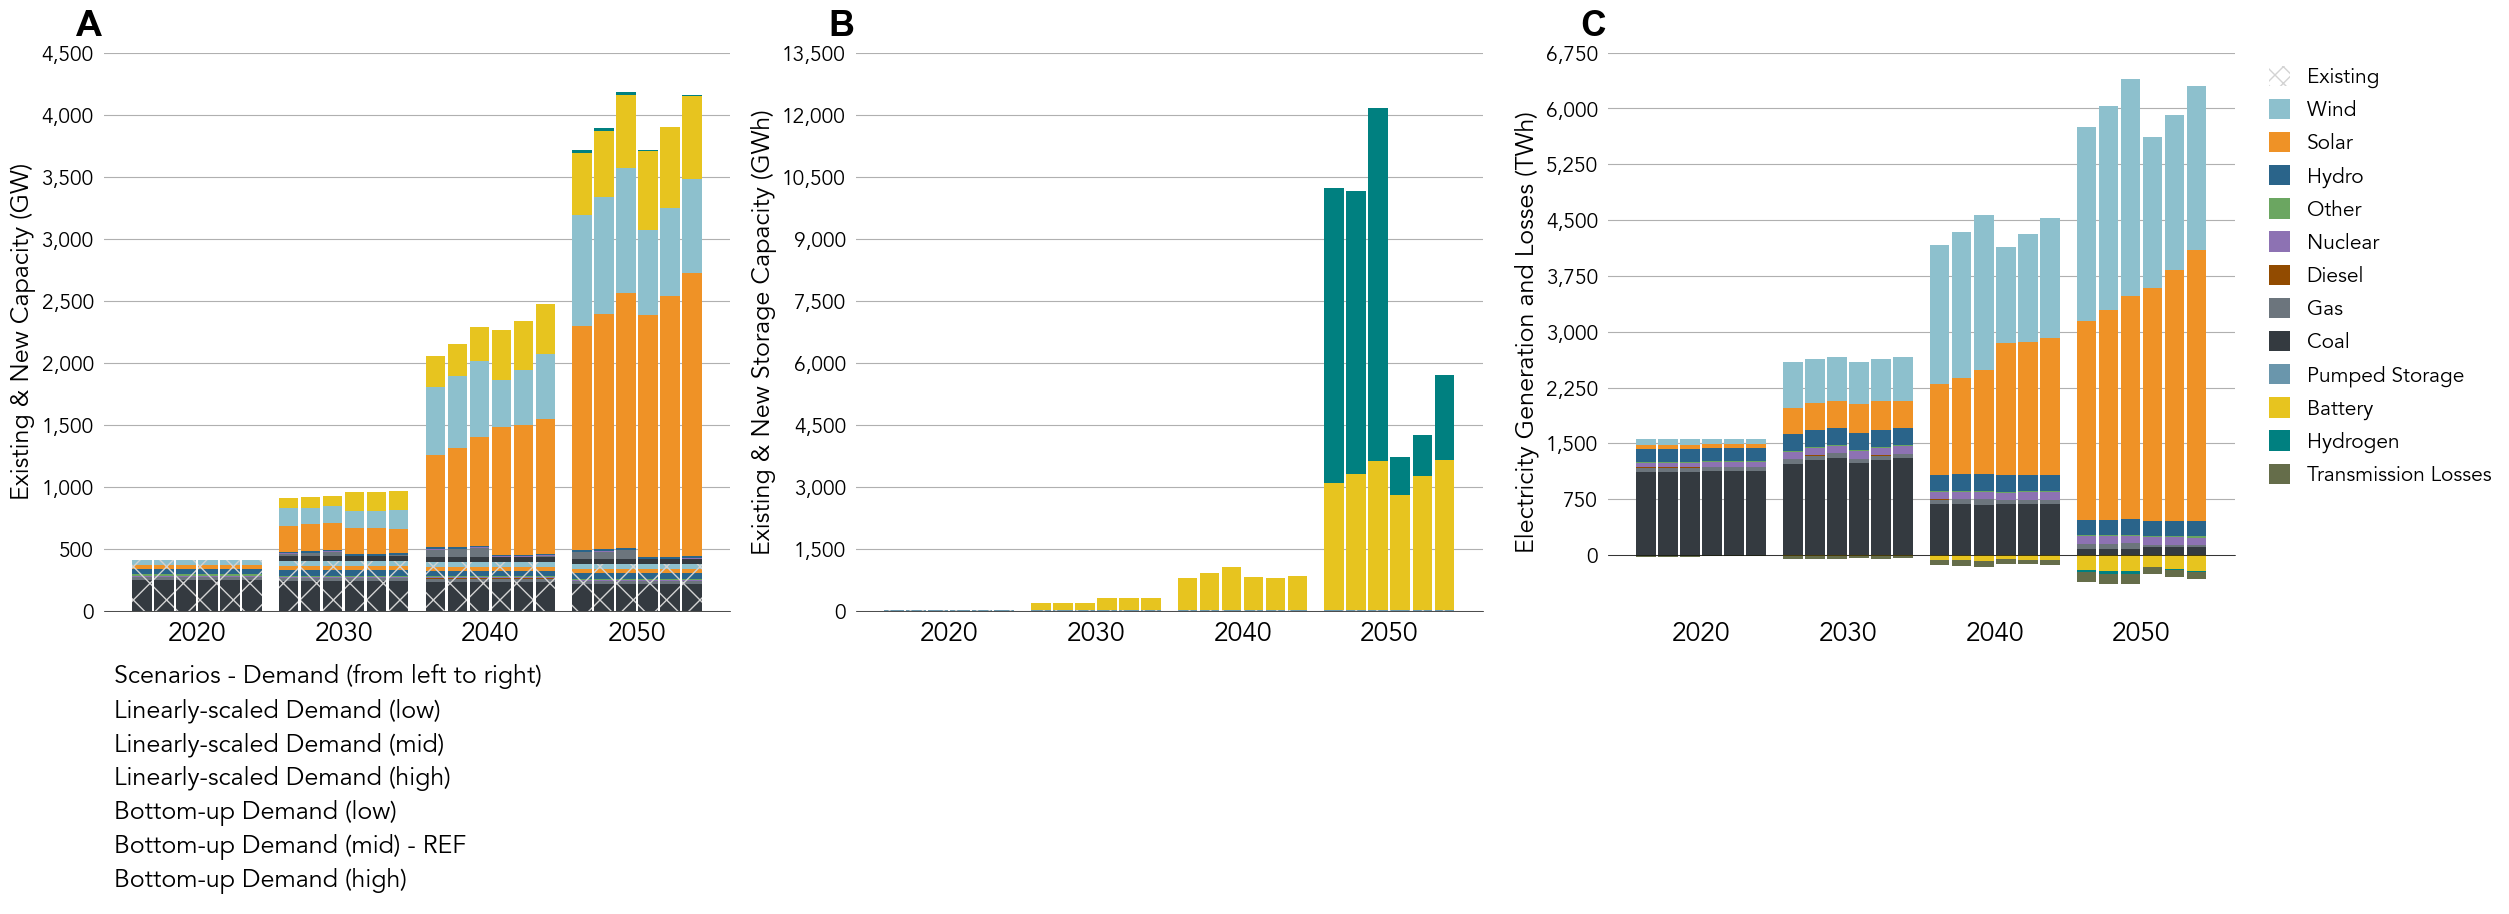

In [22]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C']], 
                              figsize = (27.5, 7.25), 
                              gridspec_kw = {'width_ratios': [1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 26, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')
    
viz._plot_new_and_existing_capacity(_ax['A'], demand_['capacity'], demand_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 4500,
                                    y_grid_inc = 500)
    

viz._plot_new_and_existing_storage(_ax['B'], demand_['capacity'], demand_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max = 13500,
                                   y_grid_inc = 1500)

viz._plot_dispatch(_ax['C'], demand_['dispatch'], demand_['scen_labels'], tech_labels_, 
                   ylabel = r'Electricity Generation and Losses (TWh)', 
                   legend = True, 
                   y_lim_max = 6750,
                   y_lim_min = -750,
                   y_grid_inc = 750)

line1    = Line2D([], [], color = 'None')
handles_ = [line1, line1, line1, line1, line1, line1]
labels_  = list(demand_['scen_labels']['label'].to_numpy())

leg = _ax['A'].legend(handles_, labels_, 
                      loc = (0., -.525),
                      title = 'Scenarios - Demand (from left to right)',
                      frameon = False,
                      labelspacing = 0.25,
                      title_fontsize = 18,
                      handletextpad = -1.,
                      ncol = 1,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/demand-capacity_generation.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/demand-capacity_generation.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [23]:
pier_ = {}
pier_['scen_labels'] = pd.read_csv(path_to_csvs + '/pier-scenario_labels.csv') 

pier_['capacity'] = ld._load_capacity(pier_['scen_labels'])
pier_['dispatch'] = ld._load_dispatch(pier_['scen_labels'])

prc._save_technology_capacity_csv(pier_['capacity'], pier_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'pier-capacity.csv')

prc._save_technology_capacity_csv(pier_['dispatch'], pier_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'pier-dispatch.csv')

pier_['capacity'] = prc._group_capacity_by_technology(pier_['capacity'], tech_labels_)
pier_['dispatch'] = prc._group_dispatch_by_technology(pier_['dispatch'], tech_labels_)

prc._save_technology_capacity_csv(pier_['capacity'], pier_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'pier-grouped_capacity.csv')

prc._save_technology_capacity_csv(pier_['dispatch'], pier_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'pier-grouped_dispatch.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/pier
VREmid_STmid_CO

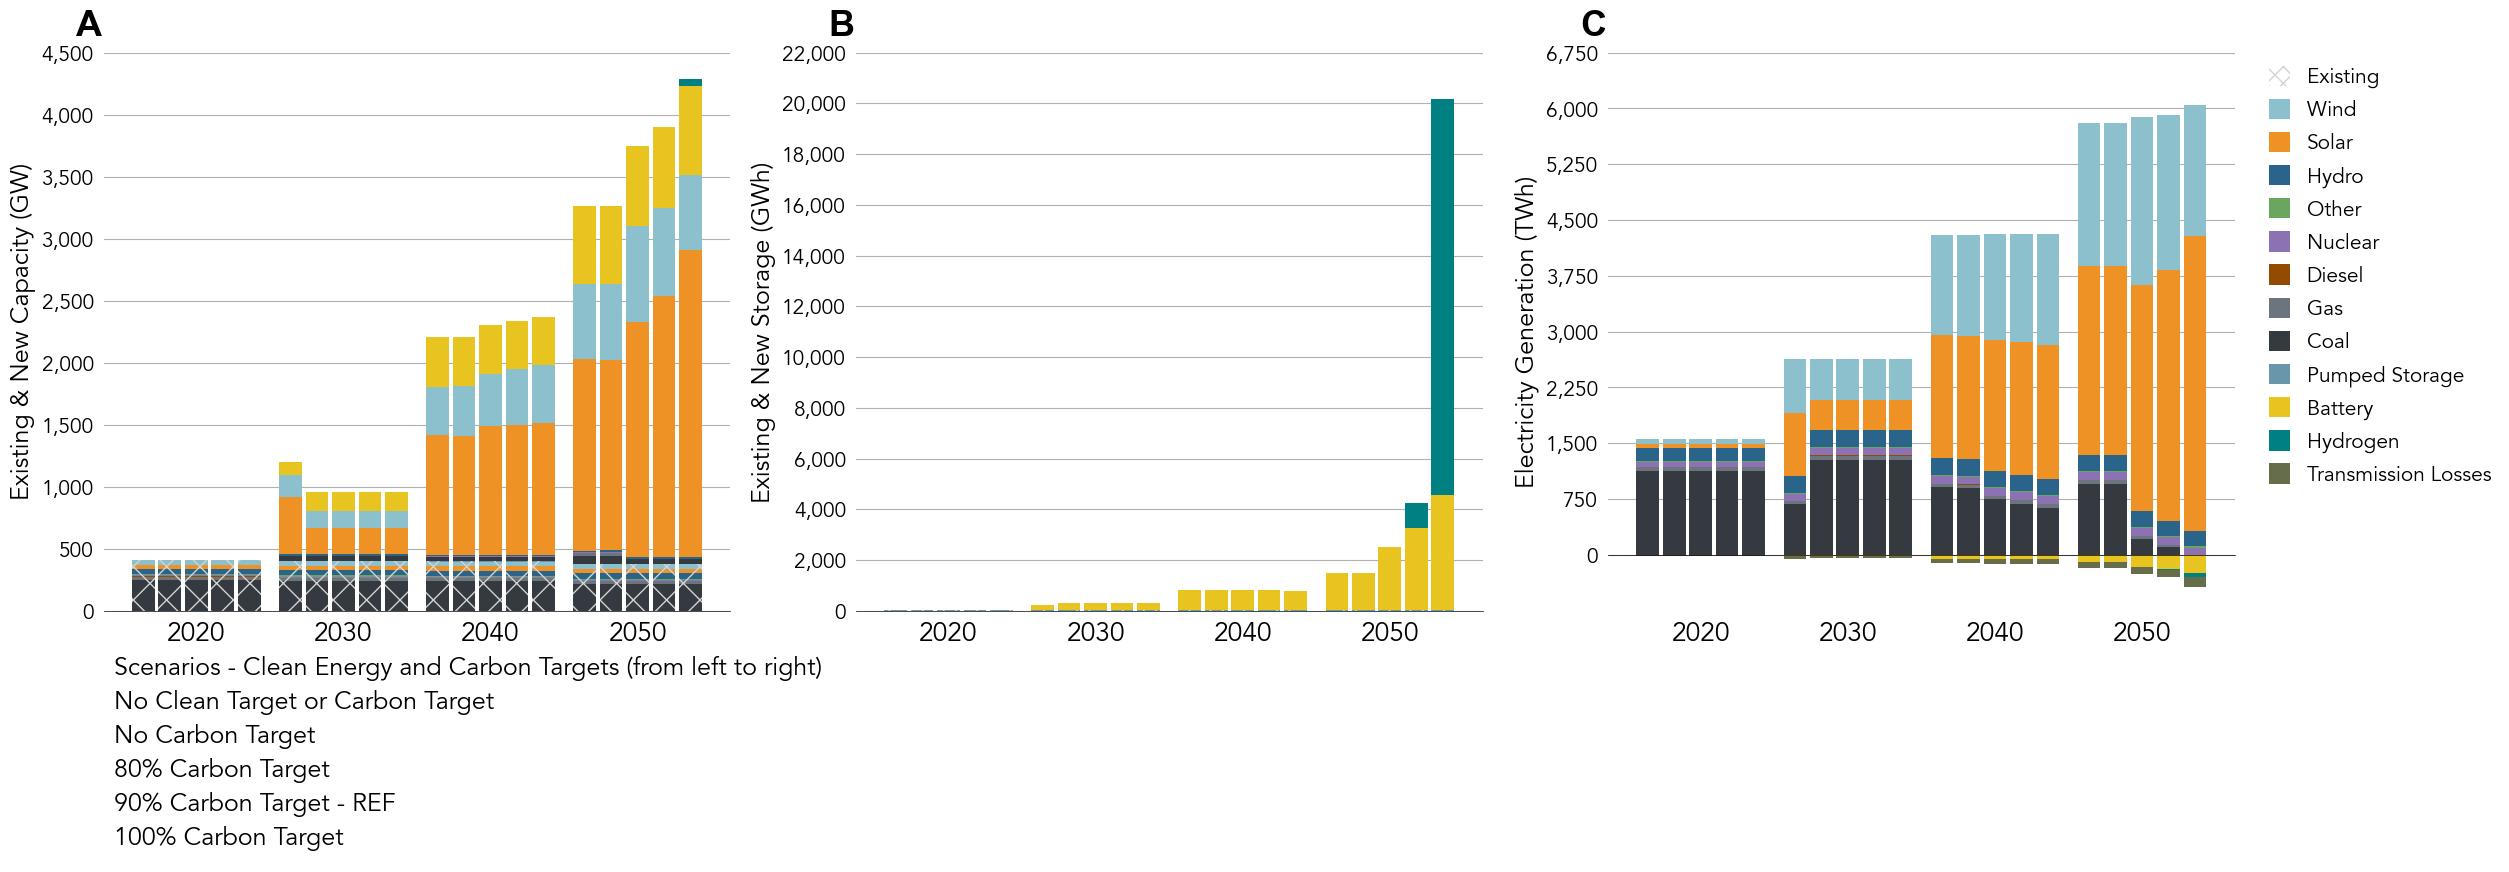

In [25]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C']], 
                              figsize = (27.5, 7.25), 
                              gridspec_kw = {'width_ratios': [1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 26, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], pier_['capacity'], pier_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 4500,
                                    y_grid_inc = 500)

viz._plot_new_and_existing_storage(_ax['B'], pier_['capacity'], pier_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage (GWh)', 
                                   legend = False,
                                   y_lim_max = 22000,
                                   y_grid_inc = 2000)

viz._plot_dispatch(_ax['C'], pier_['dispatch'], pier_['scen_labels'], tech_labels_, 
                   ylabel = r'Electricity Generation (TWh)', 
                   legend = True, 
                   y_lim_max = 6750,
                   y_lim_min = -750,
                   y_grid_inc = 750)

line1    = Line2D([], [], color = 'None')
handles_ = [line1, line1, line1, line1, line1, line1]
labels_  = list(pier_['scen_labels']['label'].to_numpy())

leg = _ax['A'].legend(handles_, labels_, 
                      loc = (0., -.45),
                      title = 'Scenarios - Clean Energy and Carbon Targets (from left to right)',
                      frameon = False,
                      labelspacing = 0.25,
                      title_fontsize = 18,
                      handletextpad = -1.,
                      ncol = 1,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-pier-capacity_generation.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-pier-capacity_generation.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [26]:
iced_ = {}
iced_['scen_labels'] = pd.read_csv(path_to_csvs + '/iced-scenario_labels.csv') 

iced_['capacity'] = ld._load_capacity(iced_['scen_labels'])
iced_['dispatch'] = ld._load_dispatch(iced_['scen_labels'])

prc._save_technology_capacity_csv(iced_['capacity'], iced_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'iced-capacity.csv')

prc._save_technology_capacity_csv(iced_['dispatch'], iced_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'iced-dispatch.csv')

iced_['capacity'] = prc._group_capacity_by_technology(iced_['capacity'], tech_labels_)
iced_['dispatch'] = prc._group_dispatch_by_technology(iced_['dispatch'], tech_labels_)

prc._save_technology_capacity_csv(iced_['capacity'], iced_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'iced-grouped_capacity.csv')

prc._save_technology_capacity_csv(iced_['dispatch'], iced_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'iced-grouped_dispatch.csv')

VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/demand
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_ICEDmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_ICEDmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_ICEDmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_ICEDmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/iced
VREmid_STmid_

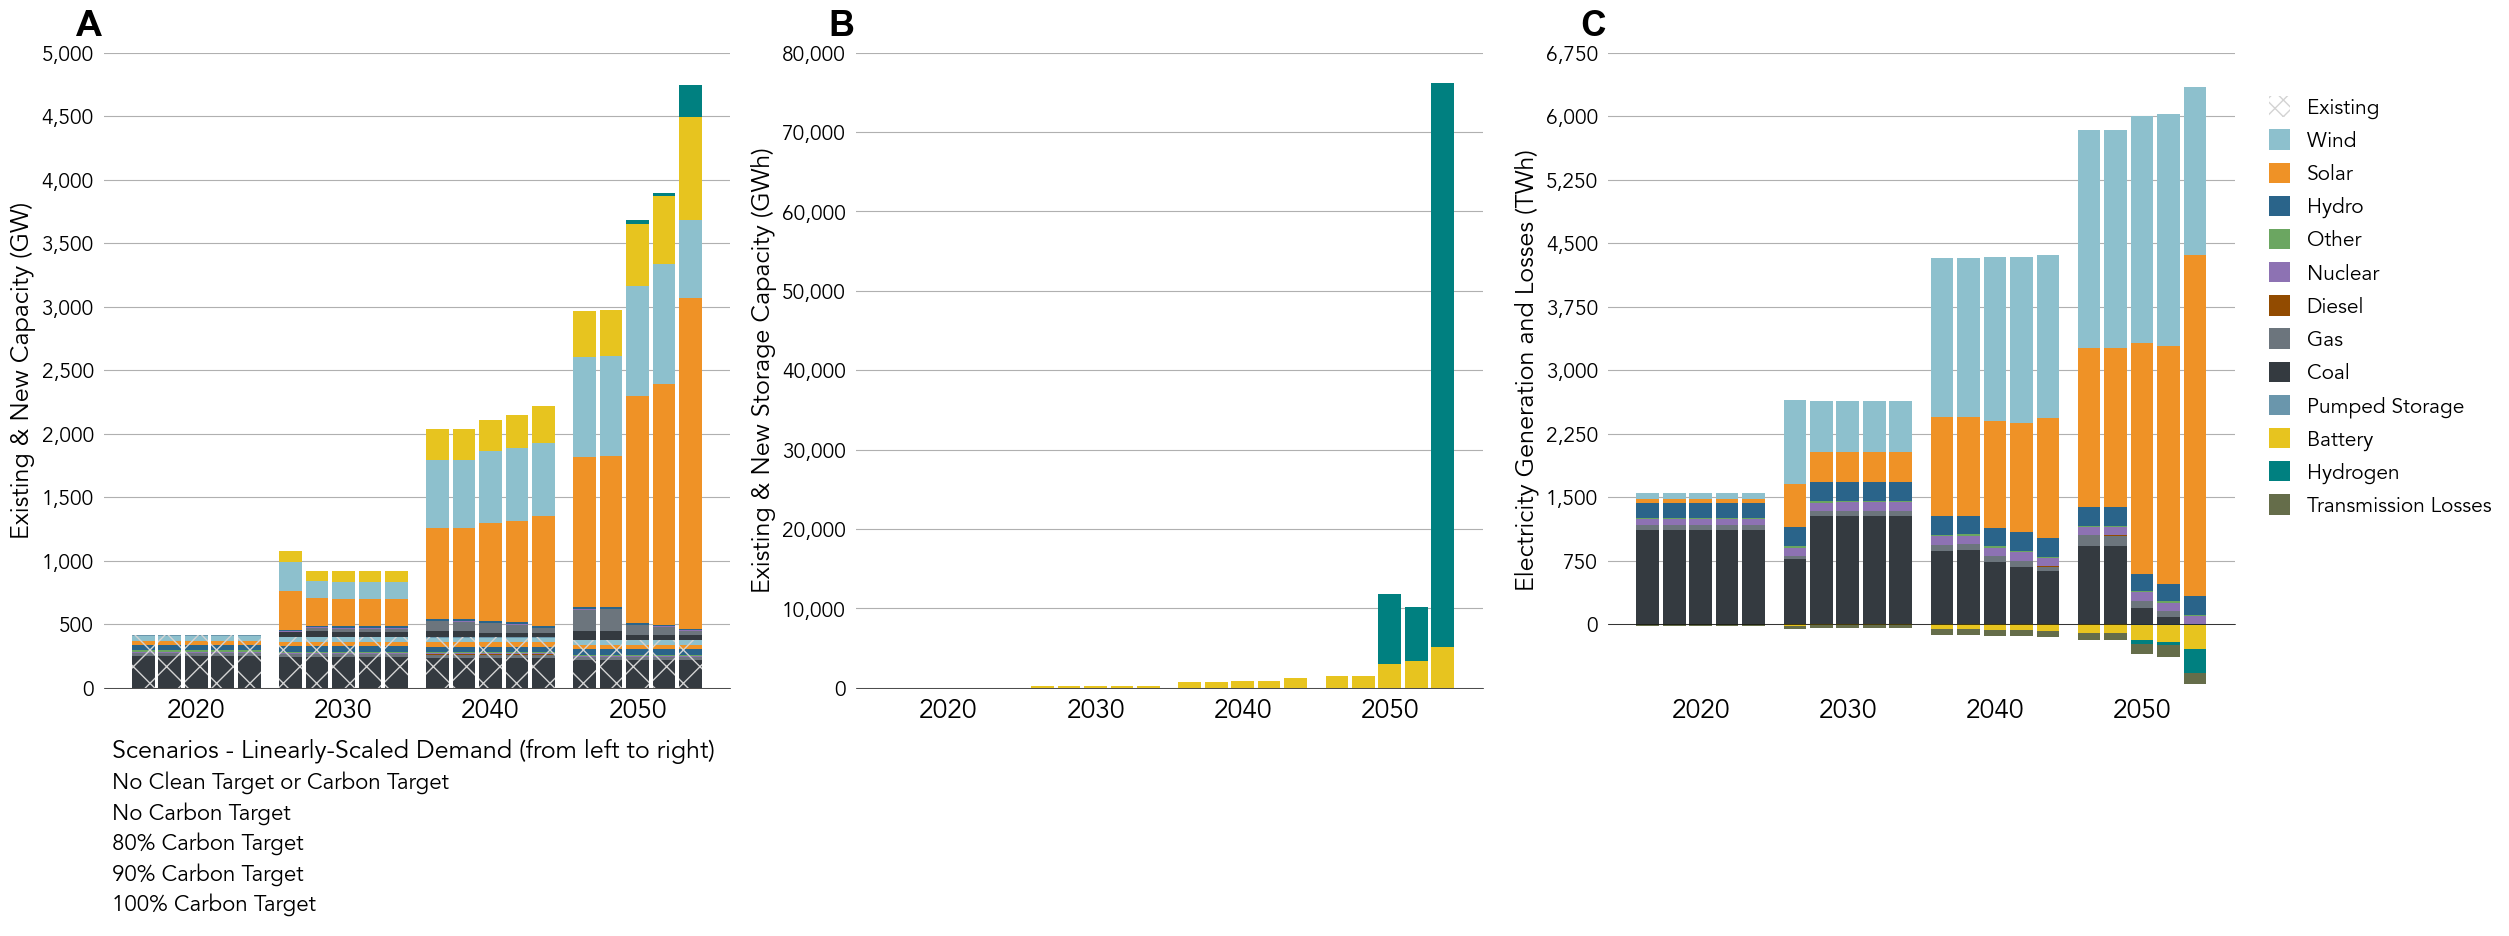

In [13]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C']], 
                              figsize = (27.5, 7.25), 
                              gridspec_kw = {'width_ratios': [1, 1, 1]})


for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 26, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], iced_['capacity'], iced_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    y_lim_max = 5000,
                                    legend = False,
                                    y_grid_inc = 500)

viz._plot_new_and_existing_storage(_ax['B'], iced_['capacity'], iced_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max = 80000,
                                   y_grid_inc = 10000)

viz._plot_dispatch(_ax['C'], iced_['dispatch'], iced_['scen_labels'], tech_labels_, 
                   ylabel = r'Electricity Generation and Losses (TWh)', 
                   legend = True, 
                   y_lim_max = 6750,
                   y_lim_min = -750,
                   y_grid_inc = 750)

line1    = Line2D([], [], color = 'None')
handles_ = [line1, line1, line1, line1, line1, line1]
labels_  = list(iced_['scen_labels']['label'].to_numpy())

leg = _ax['A'].legend(handles_, labels_, 
                      loc = (0., -.425),
                      title = 'Scenarios - Linearly-Scaled Demand (from left to right)',
                      frameon = False,
                      labelspacing = 0.25,
                      title_fontsize = 18,
                      handletextpad = -1.,
                      ncol = 1,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-iced-capacity_generation.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-iced-capacity_generation.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()

In [28]:
alternative_ = {}
alternative_['scen_labels'] = pd.read_csv(path_to_csvs + '/alternative-scenario_labels.csv') 

alternative_['capacity'] = ld._load_capacity(alternative_['scen_labels'])
alternative_['dispatch'] = ld._load_dispatch(alternative_['scen_labels'])

prc._save_technology_capacity_csv(alternative_['capacity'], alternative_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'alternative-capacity.csv')

prc._save_technology_capacity_csv(alternative_['dispatch'], alternative_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'alternative-dispatch.csv')

alternative_['capacity'] = prc._group_capacity_by_technology(alternative_['capacity'], tech_labels_)
alternative_['dispatch'] = prc._group_dispatch_by_technology(alternative_['dispatch'], tech_labels_)

prc._save_technology_capacity_csv(alternative_['capacity'], alternative_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'alternative-grouped_capacity.csv')

prc._save_technology_capacity_csv(alternative_['dispatch'], alternative_['scen_labels'], load_zones_, path_to_output, 
                                  file_name = 'alternative-grouped_dispatch.csv')

VREmid_STmid_CONVmid_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/alternative
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_PSH_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/alternative
VREmid_STmid_CONVmid_N_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/alternative
VREmid_STmid_CONVmid_H2PSHN_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid /Users/Guille/Desktop/india_power/scenarios/gridpath-india/alternative
VREmid_STmid_CONVmid_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/alternative
VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Guille/Desktop/india_power/scenarios/gridpath-india/cost
VREmid_STmid_CONVmid_PSH_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid all /Users/Gui

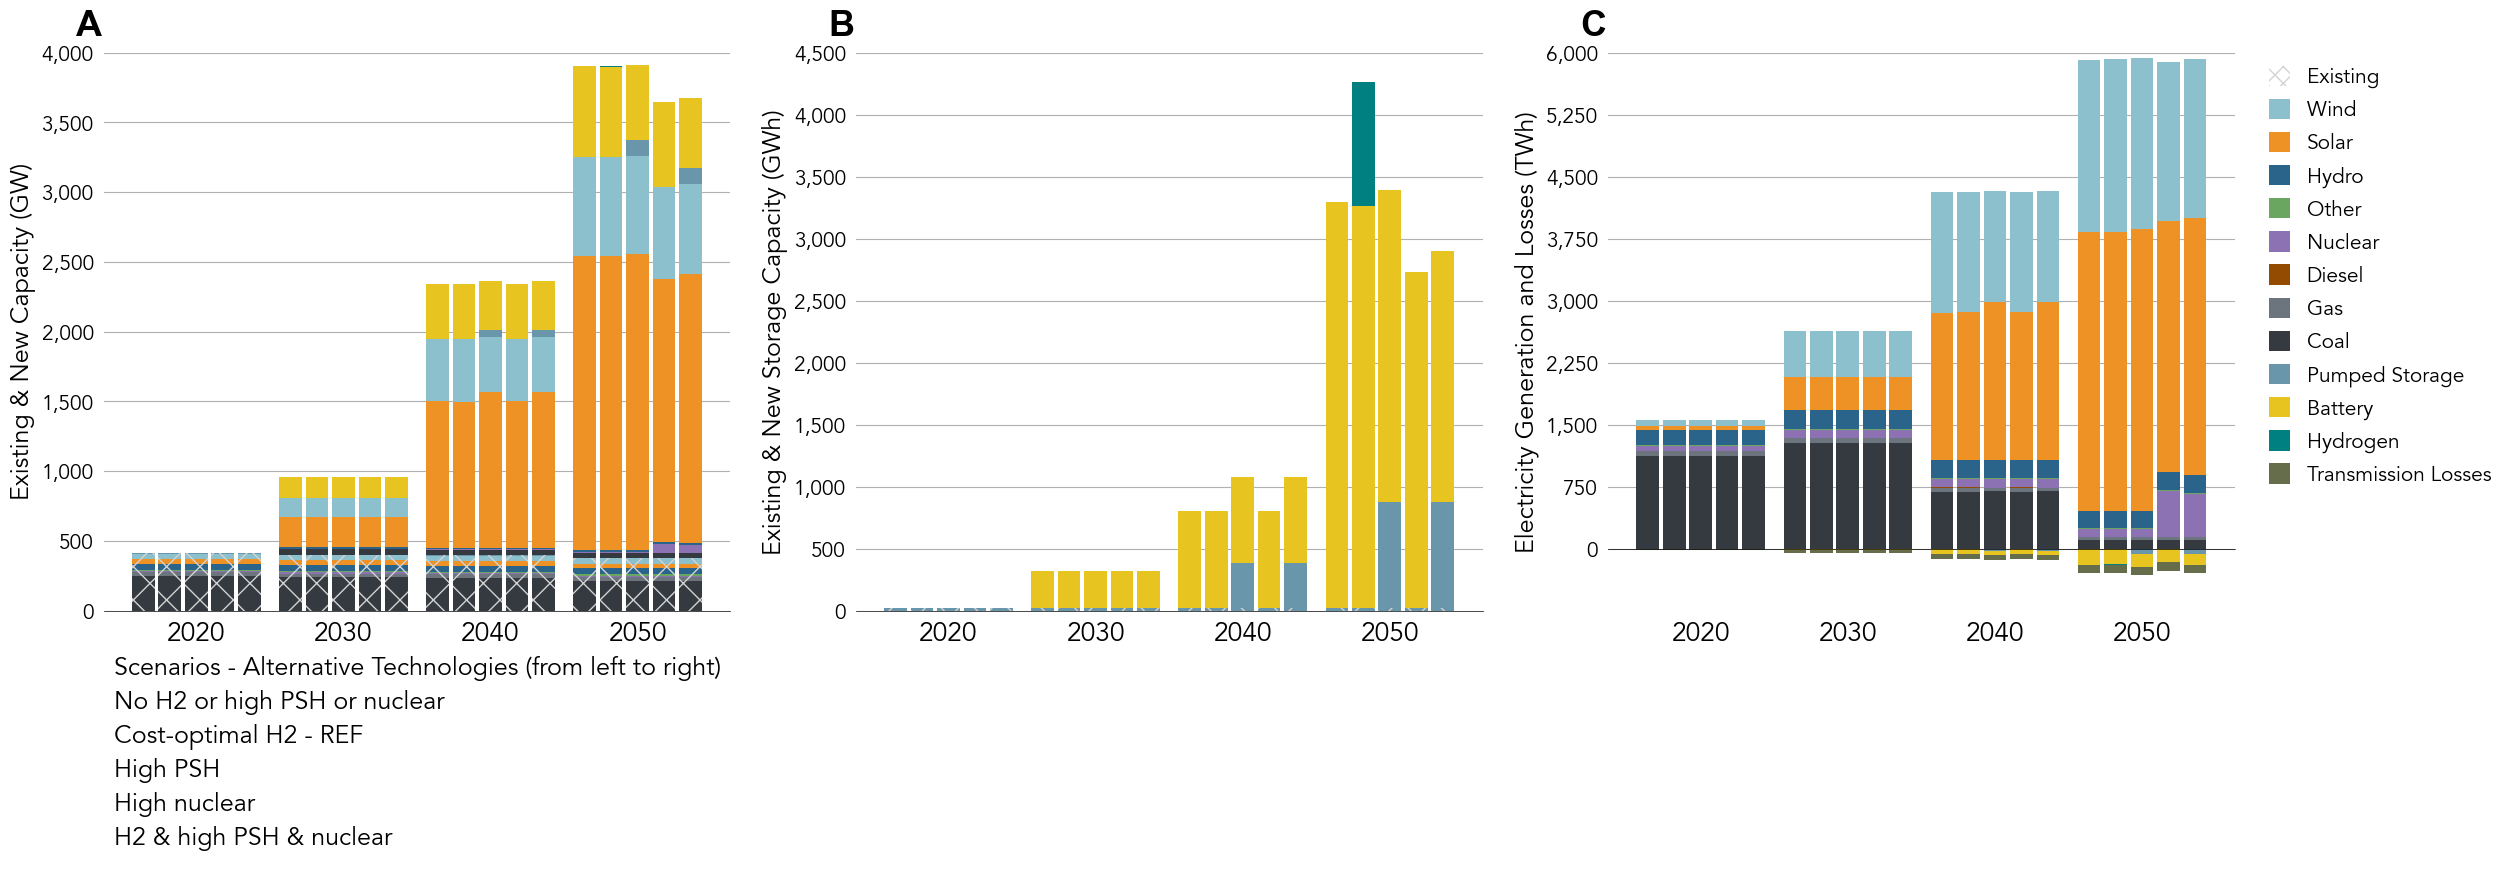

In [30]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C']], 
                              figsize = (27.5, 7.25), 
                              gridspec_kw = {'width_ratios': [1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize = 26, 
            weight = "bold",
            va = 'bottom',
            family = 'Arial')

viz._plot_new_and_existing_capacity(_ax['A'], alternative_['capacity'], alternative_['scen_labels'], tech_labels_,
                                    ylabel = 'Existing & New Capacity (GW)',
                                    legend = False,
                                    y_lim_max = 4000,
                                    y_grid_inc = 500)

viz._plot_new_and_existing_storage(_ax['B'], alternative_['capacity'], alternative_['scen_labels'], tech_labels_,
                                   ylabel = 'Existing & New Storage Capacity (GWh)', 
                                   legend = False,
                                   y_lim_max = 4500,
                                   y_grid_inc = 500)

viz._plot_dispatch(_ax['C'], alternative_['dispatch'], alternative_['scen_labels'], tech_labels_, 
                   ylabel = r'Electricity Generation and Losses (TWh)', 
                   legend = True, 
                   y_lim_max = 6000,
                   y_lim_min = -750,
                   y_grid_inc = 750)

line1    = Line2D([], [], color = 'None')
handles_ = [line1, line1, line1, line1, line1, line1]
labels_  = list(alternative_['scen_labels']['label'].to_numpy())

leg = _ax['A'].legend(handles_, labels_, 
                      loc = (0., -.45),
                      title = 'Scenarios - Alternative Technologies (from left to right)',
                      frameon = False,
                      labelspacing = 0.25,
                      title_fontsize = 18,
                      handletextpad = -1.,
                      ncol = 1,
                      prop = {'size': 18})

leg._legend_box.align = "left"

plt.savefig(path_to_images + '/SI-alternative-capacity_generation.pdf', 
            bbox_inches = 'tight')

plt.savefig(path_to_images + '/SI-alternative-capacity_generation.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show()